# 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Mounting

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Load and Explore Dataset

Load Data

In [63]:
!rsync -ah --info=progress2 "/content/drive/MyDrive/Papers/CVPR CNN Build/Pet Facial Expression Dataset" /content/

train_dir = "/content/drive/MyDrive/Papers/CVPR CNN Build/Pet Facial Expression Dataset/train"
val_dir   = "/content/drive/MyDrive/Papers/CVPR CNN Build/Pet Facial Expression Dataset/valid"
test_dir  = "/content/drive/MyDrive/Papers/CVPR CNN Build/Pet Facial Expression Dataset/test"

train_base = datasets.ImageFolder(train_dir)
val_base   = datasets.ImageFolder(val_dir)
test_base  = datasets.ImageFolder(test_dir)

              0   0%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/825) 


Check Samples and shape

In [64]:
print(f"Number of samples in training set: {len(train_base)}")
print(f"Number of samples in validation set: {len(val_base)}")
print(f"Number of samples in test set: {len(test_base)}")
print(f"Total number of samples: {len(train_base) + len(val_base) + len(test_base)}")

Number of samples in training set: 750
Number of samples in validation set: 30
Number of samples in test set: 32
Total number of samples: 812


In [65]:
from sklearn.model_selection import train_test_split
from torch.utils.data import ConcatDataset, Subset

# Make global to be accessible in subsequent cells
global full_base_dataset, train_indices, val_indices, test_indices

# Combine all base datasets (without transforms) into a single logical dataset
# This assumes train_base, val_base, test_base are ImageFolder objects as defined in 0UvwugKgWUZz
full_base_dataset = ConcatDataset([train_base, val_base, test_base])

# Extract all labels for stratification
all_labels = []
# For a ConcatDataset of ImageFolder datasets, we need to collect targets from each component
for ds in [train_base, val_base, test_base]: # Use the original base datasets to get targets
    all_labels.extend(ds.targets)

# Define the splitting ratios
train_ratio = 0.7
val_ratio = 0.1
test_ratio = 0.2

# First split: Separate test set (20%) and combined train+val set (80%)
# `stratify=all_labels` ensures the class distribution is maintained
train_val_indices, test_indices, _, _ = train_test_split(
    range(len(full_base_dataset)), # Indices of the full dataset
    all_labels,                    # Labels for stratification
    test_size=test_ratio,
    stratify=all_labels,
    random_state=42 # For reproducibility
)

# Second split: Separate train set (70% of total) and val set (10% of total)
# from the combined train+val set (80% of total)
# Calculate test_size for the second split: val_ratio / (train_ratio + val_ratio)
val_size_in_train_val = val_ratio / (train_ratio + val_ratio)
train_indices, val_indices, _, _ = train_test_split(
    train_val_indices,                             # Indices from the train+val subset
    [all_labels[i] for i in train_val_indices],    # Labels of the train+val subset for stratification
    test_size=val_size_in_train_val,
    stratify=[all_labels[i] for i in train_val_indices],
    random_state=42 # For reproducibility
)

print(f"Original total samples: {len(full_base_dataset)}")
print(f"New training set indices count: {len(train_indices)} ({len(train_indices)/len(full_base_dataset):.2%})")
print(f"New validation set indices count: {len(val_indices)} ({len(val_indices)/len(full_base_dataset):.2%})")
print(f"New test set indices count: {len(test_indices)} ({len(test_indices)/len(full_base_dataset):.2%})")

# These indices and full_base_dataset will be used in a subsequent cell (LxgPC35-WkNz)
# to create the final train_data, val_data, test_data objects with transforms.

Original total samples: 812
New training set indices count: 567 (69.83%)
New validation set indices count: 82 (10.10%)
New test set indices count: 163 (20.07%)


# 3. Data Preprocessing & Augmentation

In [66]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

Wrap datasets

In [67]:
# Define a custom Dataset class to apply transforms to Subsets
# This class wraps a torch.utils.data.Subset and applies a transform to items retrieved from it.
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self._classes = None
        # Traverse down the Subset chain to find the original ConcatDataset or ImageFolder
        original_dataset = subset
        while isinstance(original_dataset, torch.utils.data.Subset):
            original_dataset = original_dataset.dataset

        if isinstance(original_dataset, torch.utils.data.ConcatDataset) and len(original_dataset.datasets) > 0:
            # Assuming the first constituent dataset has the classes (e.g., ImageFolder)
            if hasattr(original_dataset.datasets[0], 'classes'):
                self._classes = original_dataset.datasets[0].classes
        elif hasattr(original_dataset, 'classes'): # If it was a direct ImageFolder (unlikely now)
             self._classes = original_dataset.classes

    def __getitem__(self, idx):
        x, y = self.subset[idx] # self.subset is a torch.utils.data.Subset
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

    @property
    def classes(self):
        if self._classes is not None:
            return self._classes
        raise AttributeError("Classes attribute not found in the underlying dataset.")

# Assuming full_base_dataset, train_indices, val_indices, test_indices are defined in VBjDFn68yc
# and train_transform, val_transform are defined in KWwU6BcgWdz7

train_data = TransformedSubset(Subset(full_base_dataset, train_indices), train_transform)
val_data = TransformedSubset(Subset(full_base_dataset, val_indices), val_transform)
test_data = TransformedSubset(Subset(full_base_dataset, test_indices), val_transform)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['Angry', 'Sad', 'happy']


DataLoaders

In [68]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# 4. Define CNN Architecture

Version A (WITH BatchNorm + Dropout)

In [93]:
class CNN_With_Reg(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.1), # Reduced Dropout

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2), # Reduced Dropout

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3), # Reduced Dropout

            # Added convolutional block with BatchNorm and Dropout
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3) # Reduced Dropout
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 128), # Updated input size for FC layer
            nn.ReLU(),
            nn.Dropout(0.3), # Reduced Dropout
            nn.Linear(128, 3) # Changed from 4 to 3 to match the number of classes
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

Version B (WITHOUT Regularization)

In [91]:
class CNN_Basic(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Added convolutional block
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 128), # Updated input size for FC layer
            nn.ReLU(),
            nn.Linear(128, 3) # Changed from 4 to 3 to match the number of classes
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# Architecture Summary

The Regularized CNN model consists of two main parts- a convulional base (self.conv) for feature extraction, and a fully-connected head (self.fc) for classification. It processes RGB images of size 64x64.

**Convulotional Base:**

This has 4 sequential blocks, each extracting complex features while downsampling the image. nn.Conv2d for feature mapping, 3 input channels, gradually increasing filter depth (32> 64> 128> 256). The kernel size is 3x3 with padding.

- nn.BatchNorm2d normalizes activations to stabilize and accelerate training

- nn.ReLU introduces non linearity.

- nn.MaxPool2d reduces spatial dimensions by half (2x2 kernel)

- nn.Dropout is a regularization tecnique to for overfitting prevention, with rates increasing from 0.1 to 0.3 across blocks.

**Fully connected Head (Classifier):**

- L2 Weight Decay (1e-5): Applied through the Adam  optimizer to penalize large weights.

- Data Augmentation: Applied during training with RandomHorizontalFlip, RandomRotation, RandomAffine, ColorJitter, and RandomResizedCrop to increase data variability.

- Label Smoothing (0.1): Incorporated into the nn.CrossEntropyLoss to make the model less confident about its predictions, improving generalization.

Adam optimizer over SGD was used for its adaptive learning rates for different parameters, faster convergence, and lesser manual tuning. Adam's adaptive learning rate, and fast convergence lead to a bettr performance later on for the relatively small dataset in the model.  


# Hyperparameter Tuning

In [70]:
from collections import Counter
print(Counter([y for _, y in train_data]))

Counter({2: 190, 1: 189, 0: 188})


In [74]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    # Add tqdm to the DataLoader iteration for batch-level progress
    for x, y in tqdm(loader, leave=False, desc="Training Batches"):
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()

    return total_loss/len(loader), correct/len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()

    return total_loss/len(loader), correct/len(loader.dataset)


from tqdm.auto import tqdm
from torch.utils.data import Subset

results = []

# ┅ Early stopping parameters for tuning
max_tuning_epochs = 10
patience = 3

# ┅ Create subset directly from train_data (NOT train_base)
subset_ratio = 0.2   # slightly larger since dataset is small (~1000 images)
subset_size = int(subset_ratio * len(train_data))

indices = np.random.choice(len(train_data), subset_size, replace=False)
train_subset = Subset(train_data, indices)

for bs in [16, 32, 64, 128]:
    for lr in [1e-4, 3e-4, 5e-4, 1e-3, 3e-3]: # Updated learning rates as per user request

        print(f"\nTesting BS={bs}, LR={lr}")

        train_loader_tuning = DataLoader(
            train_subset,
            batch_size=bs,
            shuffle=True,
            num_workers=0, # Changed from 2 to 0 for debugging
            pin_memory=True
        )

        val_loader_tuning = DataLoader(
            val_data,
            batch_size=bs,
            shuffle=False,
            num_workers=0, # Changed from 2 to 0 for debugging
            pin_memory=True
        )

        # ┅ NEW model each run (no overlap)
        model_tuning = CNN_With_Reg().to(device)

        optimizer_tuning = optim.Adam(model_tuning.parameters(), lr=lr, weight_decay=1e-4)
        criterion_tuning = nn.CrossEntropyLoss()

        best_val_loss = float('inf')
        epochs_no_improve = 0

        for epoch in tqdm(range(max_tuning_epochs), desc=f"Tuning BS={bs}, LR={lr}"):
            train_epoch(model_tuning, train_loader_tuning, optimizer_tuning, criterion_tuning)
            val_loss, val_acc = eval_epoch(model_tuning, val_loader_tuning, criterion_tuning)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f"Early stopping triggered for BS={bs}, LR={lr}")
                break

        results.append((bs, lr, val_acc))

# ┅ Best hyperparameters
best_bs, best_lr, best_val_acc = max(results, key=lambda x: x[2])

print(f"\n Best Hyperparameters:")
print(f"Batch Size = {best_bs}, Learning Rate = {best_lr}, Val Acc = {best_val_acc:.4f}")


Testing BS=16, LR=0.0001


Tuning BS=16, LR=0.0001:   0%|          | 0/10 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/8 [00:00<?, ?it/s]

...

Training Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Early stopping triggered for BS=128, LR=0.003

 Best Hyperparameters:
Batch Size = 32, Learning Rate = 0.001, Val Acc = 0.4390


In [72]:
train_loader = DataLoader(train_data, batch_size=best_bs, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=best_bs, shuffle=False)

model = CNN_With_Reg().to(device)
optimizer = optim.Adam(model.parameters(), lr=best_lr)

### Grid Search Results

In [73]:
import pandas as pd

# Convert results to a pandas DataFrame for better visualization
results_df = pd.DataFrame(results, columns=['Batch Size', 'Learning Rate', 'Validation Accuracy'])

# Sort by Validation Accuracy to easily see the best combinations
results_df = results_df.sort_values(by='Validation Accuracy', ascending=False).reset_index(drop=True)

print("Grid Search Hyperparameter Tuning Results:")
display(results_df)

Grid Search Hyperparameter Tuning Results:


,Batch Size,Learning Rate,Validation Accuracy
0,32,0.0010,0.487805
1,16,0.0001,0.475610
2,32,0.0005,0.463415
3,16,0.0003,0.451220
4,64,0.0030,0.439024
5,32,0.0003,0.439024
6,32,0.0001,0.426829
7,16,0.0005,0.414634
8,64,0.0001,0.414634
9,16,0.0010,0.365854


# 5. Training Loop with Validation

In [75]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    # Add tqdm to the DataLoader iteration for batch-level progress
    for x, y in tqdm(loader, leave=False, desc="Training Batches"):
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()

    return total_loss/len(loader), correct/len(loader.dataset)

Validation

In [76]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()

    return total_loss/len(loader), correct/len(loader.dataset)

Training Setup

In [87]:
model = CNN_With_Reg().to(device)

# Ensure train_loader and val_loader use the best_bs found during tuning
# This assumes best_bs and best_lr are defined from the hyperparameter tuning cell (QvOU-Zbnyj-F).
train_loader = DataLoader(train_data, batch_size=best_bs, shuffle=True,num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=best_bs, shuffle=False)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.003, # Fixed learning rate as per user request
    weight_decay=1e-5 # Reduced weight_decay
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Calculate class weights for imbalanced dataset
from collections import Counter

# Extract all grouped labels from the training dataset
# train_data is an ImageFolder dataset now, so elements are (image, label)
labels = [y for _, y in train_data]
counts = Counter(labels)

num_classes = len(class_names)

weights = torch.tensor(
    [1.0 / counts[i] if counts[i] > 0 else 1.0 for i in range(num_classes)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Added label smoothing as per user request

epochs = 100 # Updated epochs to 100
patience = 7 # Updated patience to 7

### Training Loop with Early Stopping

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 1/100: Train Loss: 2.5543, Train Acc: 0.3510, Val Loss: 1.2181, Val Acc: 0.4512


Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/100: Train Loss: 1.3319, Train Acc: 0.3580, Val Loss: 1.2194, Val Acc: 0.3659


...

Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a352c92bf60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a352c92bf60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 32/100: Train Loss: 1.1248, Train Acc: 0.5132, Val Loss: 1.1064, Val Acc: 0.5000


Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 33/100: Train Loss: 1.1200, Train Acc: 0.5115, Val Loss: 1.1063, Val Acc: 0.4756
Early stopping triggered after 33 epochs due to no improvement in validation loss for 10 consecutive epochs.


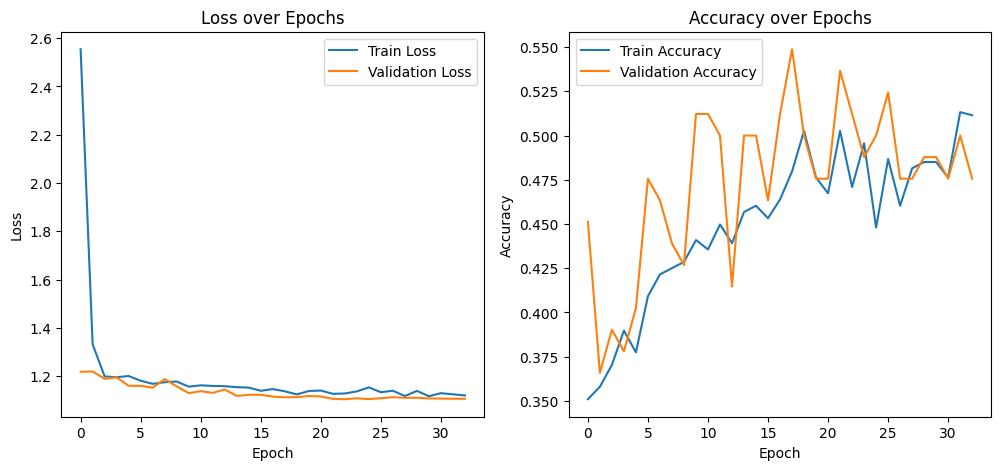

In [78]:
best_val_loss = float('inf')
patience = 10
epochs_no_improve = 0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in tqdm(range(epochs), desc="Training Progress"):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    scheduler.step() # Adjust learning rate

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optionally save the best model here
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} consecutive epochs.")
            break

# Load the best model state found during training for final evaluation
model.load_state_dict(torch.load('best_model.pth'))

# Plotting training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 6. Evaluate Model on Test Set

In [79]:
import torch.nn.functional as F

all_preds, all_labels, all_probs = [], [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)

        # Get predictions (for classification report)
        preds = out.argmax(1).cpu().numpy()

        # Get probabilities (for ROC AUC)
        probabilities = F.softmax(out, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())
        all_probs.extend(probabilities)

# 7. Visualizations

Load models (For reruns only)

In [ ]:
import os

# --- USER INPUT REQUIRED ---
# Please uncomment and update the 'model_path' variable below
# with the exact path to the model file you wish to load.
# Example: model_path = "/content/drive/MyDrive/Papers/CVPR CNN Build/Models/model_20231027_153000/emotion_loneliness_cnn.pth"
# model_path = "/content/drive/MyDrive/Papers/CVPR CNN Build/Models/model_YOUR_TIMESTAMP_HERE/emotion_loneliness_cnn.pth"
# --------------------------

# model_path = "model.pth" # Uncomment and set your model path here

# Initialize the model architecture
# Assuming CNN_With_Reg is the model architecture you want to load
model = CNN_With_Reg().to(device)

# Check if model_path is defined and exists before attempting to load
if 'model_path' in locals() and os.path.exists(model_path):
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval() # Set the model to evaluation mode after loading
        print(f"Successfully loaded model from: {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
else:
    print("Please uncomment and set 'model_path' to the desired model file in Google Drive, and ensure the path is correct.")


Confusion Matrix

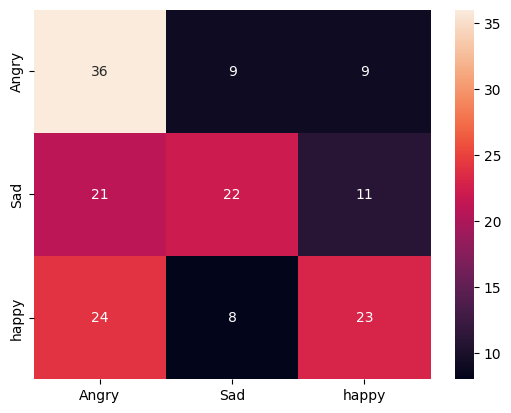

In [80]:
cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.show()

Classification Report

In [81]:
import pandas as pd
from sklearn.metrics import classification_report

# Get current training parameters
current_lr = optimizer.param_groups[0]['lr']
optimizer_name = optimizer.__class__.__name__

# Generate classification report as a dictionary
report_dict = classification_report(all_labels, all_preds, output_dict=True, target_names=class_names)

# Extract overall metrics
accuracy = report_dict['accuracy']
macro_precision = report_dict['macro avg']['precision']
macro_recall = report_dict['macro avg']['recall']
macro_f1_score = report_dict['macro avg']['f1-score']

# Create a DataFrame for summary
summary_data = {
    'Metric': [
        'Batch Size',
        'Learning Rate',
        'Optimizer',
        'Accuracy',
        'Precision (Macro Avg)',
        'Recall (Macro Avg)',
        'F1-Score (Macro Avg)'
    ],
    'Value': [
        batch_size,
        current_lr,
        optimizer_name,
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1_score
    ]
}

summary_df = pd.DataFrame(summary_data)
print("Model Evaluation Summary:")
display(summary_df)

print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Model Evaluation Summary:


,Metric,Value
0,Batch Size,32
1,Learning Rate,0.000047
2,Optimizer,Adam
3,Accuracy,0.496933
4,Precision (Macro Avg),0.514477
5,Recall (Macro Avg),0.497419
6,F1-Score (Macro Avg),0.491946



Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.44      0.67      0.53        54
         Sad       0.56      0.41      0.47        54
       happy       0.53      0.42      0.47        55

    accuracy                           0.50       163
   macro avg       0.51      0.50      0.49       163
weighted avg       0.51      0.50      0.49       163



# 8. Save Model

In [83]:
import os
from datetime import datetime

base_save_dir = "/content/drive/MyDrive/Papers/CVPR CNN Build/Models"

# Create a timestamp for the new folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_save_dir = os.path.join(base_save_dir, f"model_{timestamp}")

# Create the new directory if it doesn't exist
os.makedirs(model_save_dir, exist_ok=True)

# Define the full path for saving the model
model_path = os.path.join(model_save_dir, "pet_expression_cnn.pth")

torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Model saved to: /content/drive/MyDrive/Papers/CVPR CNN Build/Models/model_20260402_140806/pet_expression_cnn.pth


Number of trainable parameters

In [84]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 914,308


# 9. CNN Without Regularization

Initialize CNN_Basic

In [98]:
model_basic = CNN_Basic().to(device)

optimizer_basic = optim.Adam(model_basic.parameters(), lr=best_lr)

scheduler_basic = optim.lr_scheduler.StepLR(optimizer_basic, step_size=5, gamma=0.5)

criterion_basic = nn.CrossEntropyLoss(weight=weights)

Training Loop

In [97]:
epochs = 100 # Updated epochs to 100
best_val_loss_basic = float('inf')
patience = 7 # Updated patience to 7
epochs_no_improve = 0

train_losses_b, val_losses_b = [], []
train_accs_b, val_accs_b = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model_basic, train_loader, optimizer_basic, criterion_basic)
    val_loss, val_acc = eval_epoch(model_basic, val_loader, criterion_basic)

    scheduler_basic.step()

    train_losses_b.append(train_loss)
    train_accs_b.append(train_acc)
    val_losses_b.append(val_loss)
    val_accs_b.append(val_acc)

    print(f"[Basic] Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    if val_loss < best_val_loss_basic:
        best_val_loss_basic = val_loss
        epochs_no_improve = 0
        torch.save(model_basic.state_dict(), 'best_model_basic.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping (Basic)")
            break

# Load best version
model_basic.load_state_dict(torch.load('best_model_basic.pth'))

Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

[Basic] Epoch 1: Train Acc=0.3245, Val Acc=0.3293


Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

[Basic] Epoch 2: Train Acc=0.3369, Val Acc=0.3293


Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

...

Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

[Basic] Epoch 16: Train Acc=0.4991, Val Acc=0.4634


Training Batches:   0%|          | 0/18 [00:00<?, ?it/s]

[Basic] Epoch 17: Train Acc=0.5220, Val Acc=0.4512
Early stopping (Basic)


<All keys matched successfully>

Evaluate on test set

In [99]:
all_preds_b, all_labels_b = [], []

model_basic.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model_basic(x)

        preds = out.argmax(1).cpu().numpy()

        all_preds_b.extend(preds)
        all_labels_b.extend(y.numpy())

Confusion Matrix

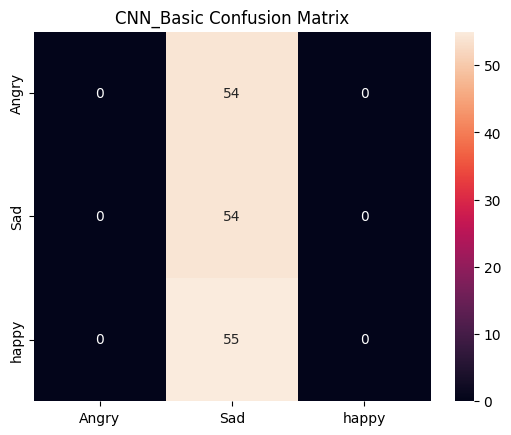

In [103]:
cm = confusion_matrix(all_labels_b, all_preds_b)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("CNN_Basic Confusion Matrix")
plt.show()

Classification report

In [104]:
print("CNN_Basic Report:\n")
print(classification_report(all_labels_b, all_preds_b, target_names=class_names))

CNN_Basic Report:

              precision    recall  f1-score   support

       Angry       0.00      0.00      0.00        54
         Sad       0.33      1.00      0.50        54
       happy       0.00      0.00      0.00        55

    accuracy                           0.33       163
   macro avg       0.11      0.33      0.17       163
weighted avg       0.11      0.33      0.16       163



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Comparison

Training comparison

In [102]:
print("=== Model Comparison ===")
print(f"CNN_With_Reg → Best Val Acc: {max(val_accs):.4f}")
print(f"CNN_Basic    → Best Val Acc: {max(val_accs_b):.4f}")

=== Model Comparison ===
CNN_With_Reg → Best Val Acc: 0.5488
CNN_Basic    → Best Val Acc: 0.5244


Test Performance comparison

In [105]:
from sklearn.metrics import accuracy_score

acc_reg = accuracy_score(all_labels, all_preds)
acc_basic = accuracy_score(all_labels_b, all_preds_b)

print(f"Test Accuracy (With Reg): {acc_reg:.4f}")
print(f"Test Accuracy (Basic):    {acc_basic:.4f}")

Test Accuracy (With Reg): 0.4969
Test Accuracy (Basic):    0.3313


Both model graphical comparison

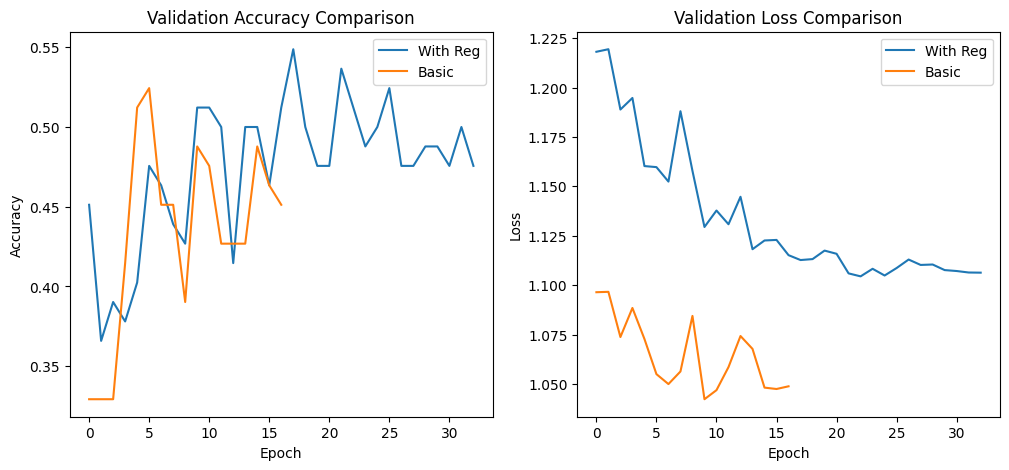

In [106]:
plt.figure(figsize=(12,5))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(val_accs, label='With Reg')
plt.plot(val_accs_b, label='Basic')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(val_losses, label='With Reg')
plt.plot(val_losses_b, label='Basic')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Confusion Matrix Comparison

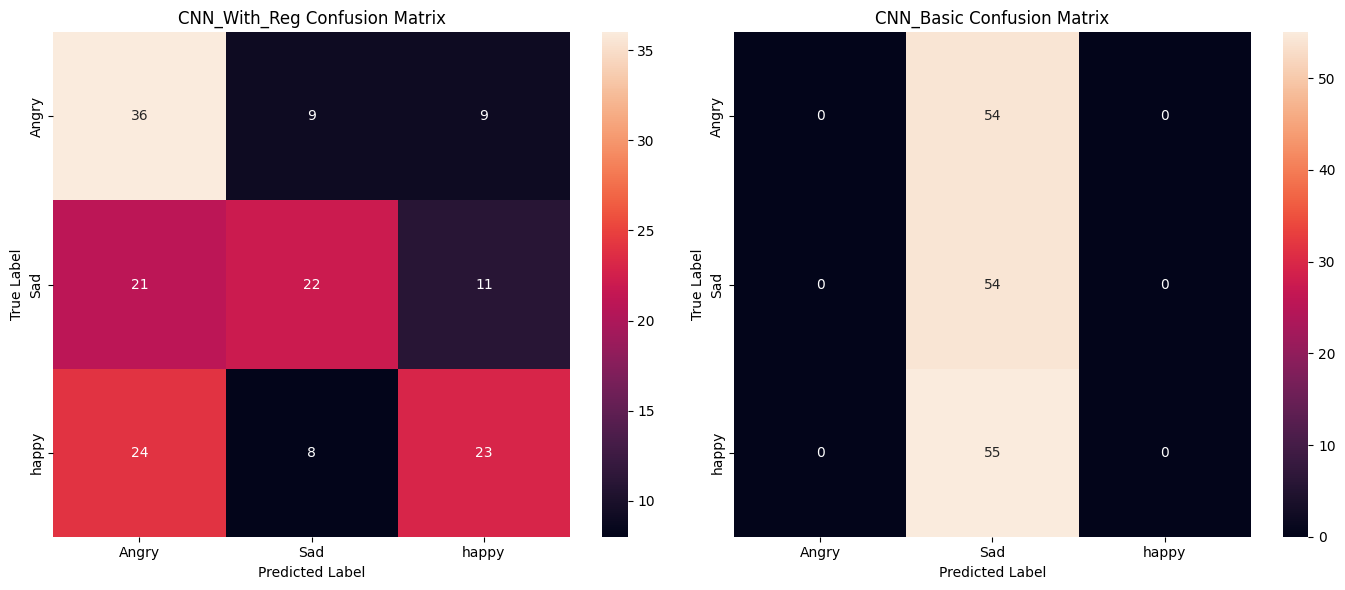

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix for CNN_With_Reg
cm_reg = confusion_matrix(all_labels, all_preds)

# Calculate confusion matrix for CNN_Basic
cm_basic = confusion_matrix(all_labels_b, all_preds_b)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_reg, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("CNN_With_Reg Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.subplot(1, 2, 2)
sns.heatmap(cm_basic, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("CNN_Basic Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# 9. Analysis and Discussion of Results




This section analyzes the experimental results from the regularized and non-regularized convulotional neural network (CNN) models, CNN_With_Reg and CNN_Basic. Here, the impact of hyperparameter tuning, dataset refinement, architectural choices and and regularization on the classification performance was evaluated. It was a three-class pet emotion recognition task, the classes being Angry, sad, Happy.

**1) Experimental Result overview:**

The CNN model with regularization impplemented achieved an accuracy of 49.69%, along with macro-averaged presion 0.514, recall of 0.497, and F1-score of 0.492. The basic CNN model without regularization achieved a significantly lower accuracy of 33.13%, which is almost close to the random baseline 25% for the problem. This shows that the regularized model generalized unseen data to a reasonable extent. But the basic model mostly failed to learn any meaningful discriminative features.

This performance gap shows how effective regalarization can be to improve generalization and preventing degenerate learning behavior.

**2) Dataset Refinement effects:**

The initial dataset included an "other" class, which lacked any consistent visual characteristics. Removing this class and restricting the problem to three-well defined categories improved the performance from around 35% validation acuracy to the present 49% accuracy.

This shows that noisy or poorly defined labels negatively affect the model's ability to learn meaningful class boundaries and have clearer distinction between emotional expressions. This captures the importance of dataset quality on supervised learning tasks, especially with subtle visual difference domains such as emotion recognition.

**3) Hyperparameter Tuning Analysis:**

The optimal combination of batch size and learning rates for the model was explored with a grid search. The results indicated that a learning rate of 0.001 with batch size 32 yielded the highest validation accuracy.

Lower learning rates (0.0001-0.0003) lead to slower convergence and subpar performance, and higher learning rates such as 0.003 led to unstable training with reduced generalization. Eventually, the current learning rate and batch size numbers were included in the final grid search for comparison, which revealed batch size 32 to outperform every other batch sizes, providing balance between gradoent stability and generalization.

These suggest that though appropriate hyperparameter selection matters for performance, the impact can be limited compared to dataset quality and model architecture.

**4) Impact of Model Architecture:**

Cnn architectures with varying depths were explored to observe the effects of increasing model complexity. Adding additional convulotional layers initially improved feature extraction, but further increases in depth did not yield to further improvements, rather diminished returns.

The smaller size of the dataset limits the model's effective training with deeper architectures, leading to overfitting. Increasing the number of layers alone was also insufficient for significant performance improvement, showing that architectural complexity must be balanced with dataset size and diversity.

**5) Regularization Effect:**

The regularization techniques deployed here were dropout, L2 weight decay, and data augmentation and label smoothing. The performance boost of the regularized model showed the effects of these strategies over the basic model.

The Basic model predicted nearly all classes as sad, displaying class collapsing. This resulted in poor overall accuracy and negligible class discrimination.

The Regularized CNN produced balanced predictions across all classes, as seen in the confusion matrix and evaluation metrics. The test and validation accuracy were also fairly similar, showing no significant overfitting due to the regularization strategies.

The dropout prevented reliance on specific neurons, L2 regularization penalized large weights, and data augmentation increased data variability for more effective training, leading to the final model's ability to generalize to unseen data and avoid degenerate solutions.

**6) Confusion Matrix Analysis:**

The confusion matrices of both the models offer further insight into how the models classified each label and their shortcomings.

**Regularized CNN:**

True Labels (Rows):

*Angry (Row 0):* Out of 54 actual Angry images, 36 were
correctly predicted. 9 were misclassifed as sad, 9 as happy.


*Sad (Row 1):* Out of 54 actual Sad images, 21 were misclassified as Angry, 22 as correctly Sad, and 11 misclassifed Happy.


*Happy (Row 2):* Out of 55 Happy images, 24 were misclassifed as Angry, 8 as Sad, and 23 were correct Happy predictions.


**Basic CNN:**
True Labels (Rows):

*Angry (Row 0):* All of 54 actual Angry images were misclassifed as sad.


*Sad (Row 1):* All of 54 actual Sad images were correctly classifed.


*Happy (Row 2):* All the actual Happy images were classifed as Sad.

All in all the the basic model predicts almost every image as Sad. This behavior suggests the model's inability to learn any meaningful patterns and is likely overfitting or converging into a degenrate solution. This highlights the importance of reguilarization in preventing overfitting and enabling the model to learn generalizable features, especially with smaller datasets or complex architectures.

**7. Limitations:**

The overall accuracy remained moderate (~50%) in the regular model even after the dataset refinement and regularizations. This highlights several limitations-



*   The small dataset restricts the model's ability to learn robust feature representations.
*   Facial emotion classes show ambiguity and overlap that could lead to classification confusion.


*   The model is trained from scratch, so it lacks any prior knowledge of general visual features.

These factors limit the maximum achievable performace of the model without any enhancements.





# Conclusion and Future Works:

The experiments demonstrate that dataset quality and regularization techniques can greatly impact modelperformance than architectural complexity alone. Removing the ambiguous "other" category, applying regularization significantly boosted both the accuracy and the generalization, and hyperparameter tuning provided incremental gains.

For Future works, the model can be further improved by-


*   Using transfer learning from pre-trained models such as ResNET, VGG
*   Expanding the dataset to include more diverse and high quality samples



*   Applying more advanced data augmentation techniques
*   Fine-tuning hyperparameters using more exhaustive seraching strategies.

Overall, the results show how important  balanced dataset design can be, along with appropriate regularization, and systematic experimentation in development ofeffective image classifier deep-learnings models.






